# ML S3 · Notebook 04 — The Confusion Matrix, Built by Hand

| | |
|---|---|
| **Session ID** | ML S3 · Notebook 04 of 05 |
| **Course position** | Machine Learning — Session 4 of 10 · **post-break** |
| **Block types** | 🧠 **Muscle block — no AI assistance.** Every metric is derived by hand before sklearn is opened. |
| **Prerequisites** | Notebook 02 (StratifiedKFold) · Notebook 03 (metrics as a business choice) |
| **Connects back to** | **Notebook 03** — the same argument, now for classification. **ML S1** — the accuracy you used casually on day one. |
| **Connects forward to** | **Notebook 05** (is A better than B?) · **ML S6** (thresholds, ROC/PR curves) · **ML S10** (CEP clinic) |
| **CEP linkage** | **This notebook is the direct answer to a graded requirement.** Employee Turnover asks: *"Explain which metric needs to be used from the confusion matrix: Recall or Precision?"* Section 7 is that answer. |
| **Run requirements** | `pandas`, `numpy`, `scikit-learn`. Run `ML_S3_00_datasets.ipynb` first. |
| **Checkpoint file** | `subscription_churn.csv` |

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain why accuracy is dangerous** on imbalanced problems, and show a useless model that is 80% accurate.
2. **Build a confusion matrix by hand** from raw predictions, without `sklearn`.
3. **Derive precision, recall, specificity and F1 from the four cells**, and state what each measures.
4. **Say what a false positive and a false negative *cost*** in a specific business context.
5. **Argue for recall or precision from that cost** — in writing, which is what your CEP requires.
6. **Read a classification report** without needing to look anything up.

## Table of Contents

| § | Section | Type |
|---|---|---|
| 1 | Why we changed dataset | Intuition |
| 2 | The 80% accurate useless model | 🧠 Muscle |
| 3 | The four outcomes | Core |
| 4 | The confusion matrix, by hand | 🧠 Muscle |
| 5 | The metrics, derived from the four cells | 🧠 Muscle |
| 6 | Confirming against sklearn | Core |
| 7 | **Recall or precision? The CEP question** | 🎯 CEP |
| 8 | F1, and when averaging is the wrong move | Core |
| — | Common Pitfalls · FAQ · Conclusion | Wrap-up |

# 1. Why we changed dataset

Notebook 03 ended with a promise: *a price cannot be a false positive.*

That is the whole reason for the switch. MAE, RMSE, R² and MAPE all measure **how far off** a number is. Classification has no notion of "how far off" — a prediction is either right or wrong, and when it is wrong, it is wrong **in one of two distinct directions.**

Those two directions usually have completely different costs. That asymmetry is what the rest of this notebook is about, and it is why classification needs its own vocabulary rather than a translation of the regression one.

We use `subscription_churn.csv` — 12,000 customers, and the question is whether each one cancels next quarter.

In [3]:
import numpy as np
import pandas as pd

churn = pd.read_csv('subscription_churn.csv')
print("Shape:", churn.shape)
print(f"\nTarget balance:")
print(churn.churned.value_counts().rename({0: 'stayed', 1: 'churned'}).to_string())
print(f"\nChurn rate: {churn.churned.mean():.1%}")

Shape: (12000, 13)

Target balance:
churned
stayed     9618
churned    2382

Churn rate: 19.9%


# 2. The 80% accurate useless model

> 🧠 **Muscle block.**

**Accuracy** is the fraction of predictions that were correct. It is the metric everyone reaches for first, and on an imbalanced problem it is actively misleading.

Here is the shortest possible demonstration.

### Worked Example 1 — A model with no model in it

In [4]:
class PredictsNobodyChurns:
    # A "model" that ignores every feature and always says 'stayed'.
    def fit(self, X, y):
        return self
    def predict(self, X):
        return np.zeros(len(X), dtype=int)

from sklearn.model_selection import train_test_split

X = churn.drop(columns='churned')
y = churn['churned']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lazy = PredictsNobodyChurns().fit(X_tr, y_tr)
lazy_pred = lazy.predict(X_te)

accuracy = (lazy_pred == y_te).mean()
print(f"Accuracy of a model containing no model: {accuracy:.1%}")
print(f"\nCustomers it correctly identified as at risk: {((lazy_pred == 1) & (y_te == 1)).sum()}")
print(f"Customers who actually churned:              {(y_te == 1).sum()}")

Accuracy of a model containing no model: 80.2%

Customers it correctly identified as at risk: 0
Customers who actually churned:              476


**80% accurate. Zero value.**

It found none of the 476 customers who cancelled. As a retention tool it is worse than useless — it would tell the business there is no problem.

And yet if you reported "80% accuracy" in a status update, it would sound like progress.

> ### 🌱 Just-in-Time — the accuracy floor
>
> On any classification problem, **the majority-class rate is the floor**, not the starting line. Here it is 80.2%.
>
> Before you celebrate any accuracy figure, compute the majority-class rate and subtract. A model at 82% accuracy on this data has gained less than two points over predicting nothing at all.
>
> `sklearn.dummy.DummyClassifier(strategy='most_frequent')` gives you this floor in one line. It is the classification counterpart of the `DummyRegressor` baseline from Notebook 03 — and it is just as non-negotiable.

### Worked Example 2 — The floor, and a real model against it

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols = ['tenure_months', 'monthly_charges', 'total_charges', 'num_support_tickets_6m',
            'avg_monthly_usage_gb', 'late_payments_12m', 'has_premium_support',
            'num_services', 'age', 'satisfaction_score']
cat_cols = ['contract_type', 'region']

prep = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

logreg = Pipeline([('prep', prep), ('model', LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)
dummy  = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)

print(f"  Majority-class floor : {(dummy.predict(X_te) == y_te).mean():.4f}")
print(f"  Logistic regression  : {(logreg.predict(X_te) == y_te).mean():.4f}")
print(f"\n  Gain over doing nothing: {(logreg.predict(X_te)==y_te).mean() - (dummy.predict(X_te)==y_te).mean():+.4f}")

  Majority-class floor : 0.8017
  Logistic regression  : 0.8533

  Gain over doing nothing: +0.0517


A real model, with real signal, on a genuinely predictable problem — and accuracy improves by about five points over a model that does nothing.

**Accuracy compressed a large difference into a small-looking number.** That is its failure mode: on imbalanced data it spends most of its range describing the majority class, leaving very little room to express how well you handle the minority — which is the class you actually care about.

We need metrics that look at the two error directions separately.

# 3. The four outcomes

Every prediction on a binary problem falls into exactly one of four boxes. Two are correct, two are mistakes — and the two mistakes are **different mistakes**.

We call the class we care about the **positive** class. Here that is `churned = 1`. (Note the convention: "positive" means *the thing we are trying to detect*, not *a good outcome*. Detecting churn, disease and fraud are all "positive" classes.)

| | What it means | In our problem |
|---|---|---|
| **True Positive (TP)** | Predicted churn, they churned | Correctly flagged an at-risk customer |
| **False Positive (FP)** | Predicted churn, they stayed | Wasted a retention offer on someone who was staying |
| **True Negative (TN)** | Predicted stay, they stayed | Correctly left a happy customer alone |
| **False Negative (FN)** | Predicted stay, they churned | **Missed someone. They left.** |

> ### 🌱 Just-in-Time — how to read the names without memorising them
>
> Each name is two words, and each word means something specific:
>
> - The **second** word is **what the model predicted** — Positive or Negative.
> - The **first** word is **whether the model was right** — True or False.
>
> So a *False Negative* is a **Negative prediction** that was **wrong**. The model said "stay", and it was mistaken — the customer left.
>
> Read the second word first. It works every time and you never have to memorise the table.

<div align="center">


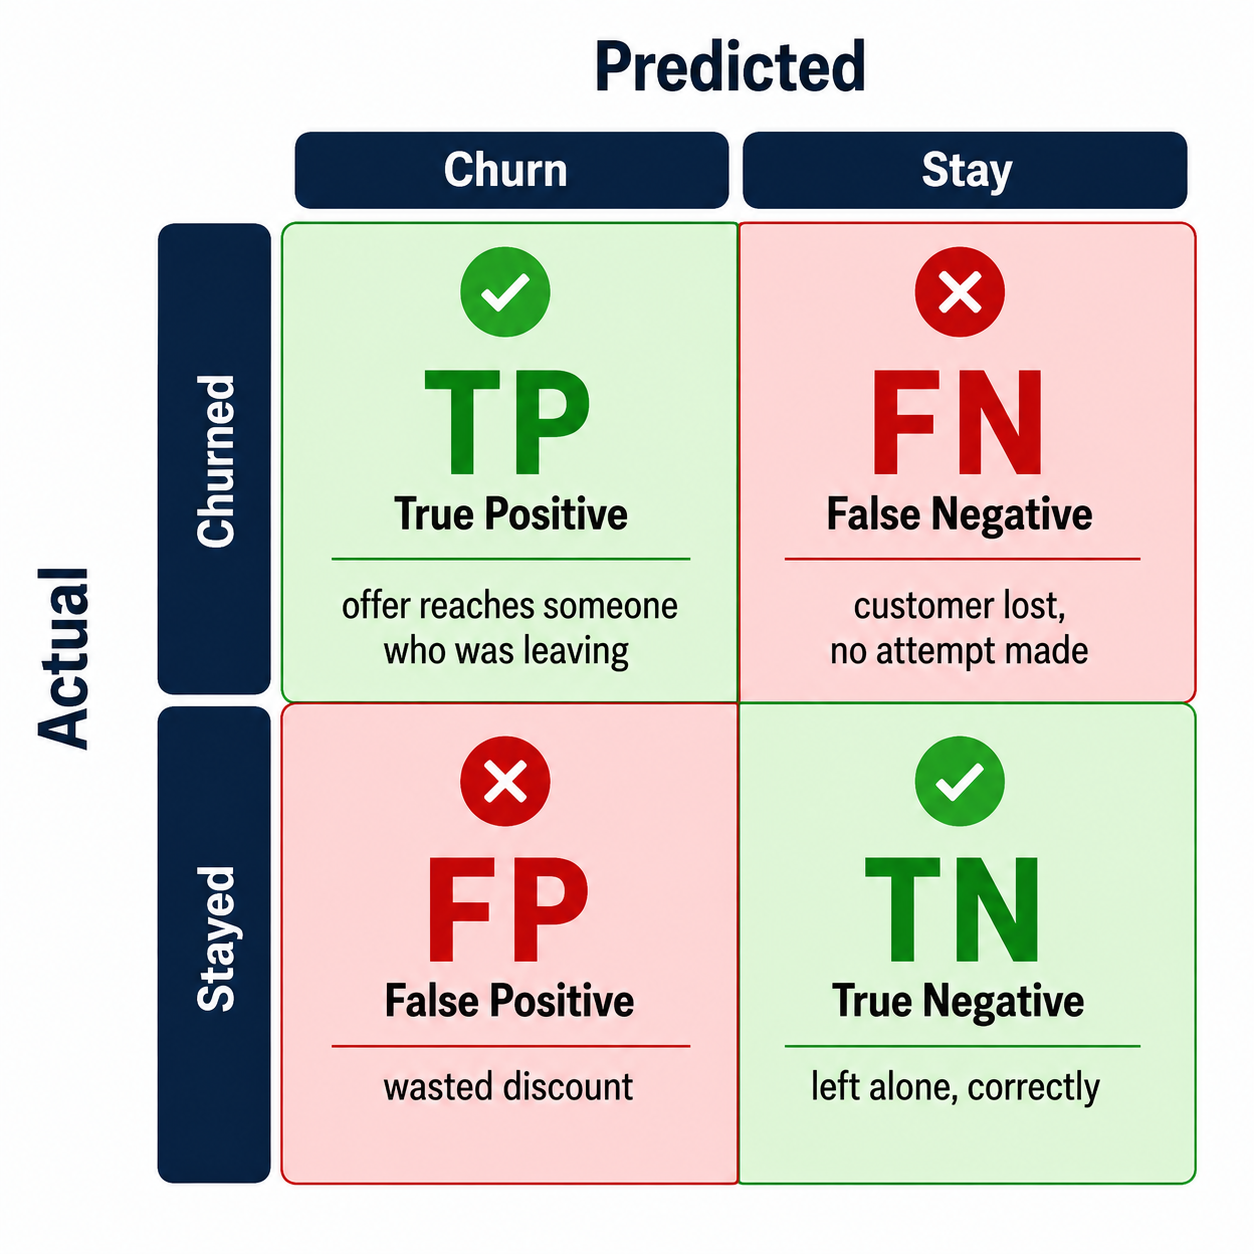

<p>
<b>Figure 1.</b> Confusion Matrix
</p>

</div>

### 🖼️ Image Slot — The four outcomes as a 2×2 grid

**What to show:** A 2x2 grid with 'Actual' on rows (Churned / Stayed) and 'Predicted' on columns (Churn / Stay). Fill the diagonal cells green (TP top-left, TN bottom-right) and the off-diagonal cells red (FN top-right, FP bottom-left). Inside each cell put the abbreviation, the full name, and a one-line business consequence: TP 'offer reaches someone who was leaving', FP 'wasted discount', FN 'customer lost, no attempt made', TN 'left alone, correctly'. Keep the orientation identical to sklearn's confusion_matrix output.

**Why here:** The grid IS the mental model. Matching the orientation to sklearn's output prevents the single most common downstream error — reading the matrix transposed.

**Placement:** Immediately after the four-outcomes table, before Section 4.

**Alt text:** Two-by-two confusion matrix grid showing true and false positives and negatives with business consequences.

<!-- INSERT IMAGE: s3_04_confusion_grid.png -->

# 4. The confusion matrix, by hand

> 🧠 **Muscle block — no AI assistance, and no `sklearn.metrics` until Section 6.**

The confusion matrix is just those four counts, arranged in a square. Nothing more.

### Worked Example 3 — Twelve customers, counted by eye

Small enough that you can verify every number yourself before trusting any code.

In [6]:
demo = pd.DataFrame({
    'customer': [f'C{i:02d}' for i in range(1, 13)],
    'actual':    [1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1],
    'predicted': [1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0],
})

def label_outcome(row):
    if row.actual == 1 and row.predicted == 1: return 'TP'
    if row.actual == 0 and row.predicted == 1: return 'FP'
    if row.actual == 0 and row.predicted == 0: return 'TN'
    return 'FN'

demo['outcome'] = demo.apply(label_outcome, axis=1)
demo

,customer,actual,predicted,outcome
0,C01,1,1,TP
1,C02,0,0,TN
2,C03,1,0,FN
3,C04,0,0,TN
4,C05,0,1,FP
5,C06,1,1,TP
6,C07,0,0,TN
7,C08,0,0,TN
8,C09,1,1,TP
9,C10,0,0,TN


In [7]:
# Count them by hand
TP = ((demo.actual == 1) & (demo.predicted == 1)).sum()
FP = ((demo.actual == 0) & (demo.predicted == 1)).sum()
TN = ((demo.actual == 0) & (demo.predicted == 0)).sum()
FN = ((demo.actual == 1) & (demo.predicted == 0)).sum()

print(f"  TP = {TP}    FP = {FP}")
print(f"  FN = {FN}    TN = {TN}")
print(f"\n  total = {TP+FP+TN+FN}  (should be {len(demo)})")

  TP = 3    FP = 2
  FN = 2    TN = 5

  total = 12  (should be 12)


In [8]:
# Arrange as a matrix, in the same orientation sklearn uses
matrix = pd.DataFrame(
    [[TN, FP],
     [FN, TP]],
    index=['actual: stayed', 'actual: churned'],
    columns=['predicted: stay', 'predicted: churn'],
)
matrix

,predicted: stay,predicted: churn
actual: stayed,5,2
actual: churned,2,3


**Check it against the table above by eye.** Three true positives (C01, C06, C09), two false positives (C05, C11), five true negatives, two false negatives (C03, C12). The counts sum to twelve.

That is the entire object. Every classification metric you will ever use is arithmetic on those four numbers.

> **On orientation:** sklearn puts **actuals on the rows** and **predictions on the columns**, with the negative class first. So the top-left is TN and the bottom-right is TP. Other tools — and many textbooks — transpose this. Always check which convention you are looking at before interpreting a matrix, because a transposed matrix silently swaps precision and recall.

### Worked Example 4 — The real thing, on 2,400 test customers

In [9]:
def confusion_by_hand(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        'TP': int(((y_true == 1) & (y_pred == 1)).sum()),
        'FP': int(((y_true == 0) & (y_pred == 1)).sum()),
        'TN': int(((y_true == 0) & (y_pred == 0)).sum()),
        'FN': int(((y_true == 1) & (y_pred == 0)).sum()),
    }

lr_pred = logreg.predict(X_te)
cm = confusion_by_hand(y_te, lr_pred)

print("Logistic regression on 2,400 held-out customers:\n")
print(f"  TP = {cm['TP']:4d}   correctly flagged as at-risk")
print(f"  FP = {cm['FP']:4d}   flagged, but would have stayed")
print(f"  FN = {cm['FN']:4d}   MISSED — churned with no intervention")
print(f"  TN = {cm['TN']:4d}   correctly left alone")
print(f"\n  total = {sum(cm.values())}")

Logistic regression on 2,400 held-out customers:

  TP =  225   correctly flagged as at-risk
  FP =  101   flagged, but would have stayed
  FN =  251   MISSED — churned with no intervention
  TN = 1823   correctly left alone

  total = 2400


Now look at `FN` against `TP`. The model found some at-risk customers — and missed more than it found.

Accuracy reported this same model as respectable. The confusion matrix shows what that accuracy was made of: it is very good at the easy majority and poor at the thing you built it for.

**That is information accuracy structurally cannot give you**, and it took four counts to expose.

# 5. The metrics, derived from the four cells

> 🧠 **Muscle block.** Derive each one, state what it asks, then compute it.

Each metric is a fraction of the four counts, and each answers a different question. The trick to remembering them is to notice **what is in the denominator** — that tells you what the metric is a fraction *of*.

**Precision** — "when it says churn, how often is it right?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

Denominator: **everything the model flagged.** Precision is about the reliability of a positive prediction. Low precision means you are crying wolf.

**Recall (Sensitivity)** — "of the people who actually churned, how many did we catch?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

Denominator: **everyone who actually churned.** Recall is about coverage. Low recall means people are slipping past you.

**Specificity** — "of the people who stayed, how many did we correctly leave alone?"

$$\text{Specificity} = \frac{TN}{TN + FP}$$

The mirror image of recall, for the negative class.

**F1** — the harmonic mean of precision and recall

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

One number when you need one number. Section 8 covers when that is a bad idea.

> ### 🌱 Just-in-Time — the one-line way to keep precision and recall straight
>
> - **Precision** is a fraction of **what you flagged**. It is judged by your *predictions*.
> - **Recall** is a fraction of **what was actually there**. It is judged by *reality*.
>
> Or: precision asks *"how much of what I caught was real?"*; recall asks *"how much of what was real did I catch?"*

### Worked Example 5 — All four, by hand, on the twelve-customer demo

In [19]:
precision   = TP / (TP + FP)
recall      = TP / (TP + FN)
specificity = TN / (TN + FP)
f1          = 2 * precision * recall / (precision + recall)

print(f"  Precision   = TP/(TP+FP) = {TP}/({TP}+{FP}) = {TP}/{TP+FP} = {precision:.3f}")
print(f"  Recall      = TP/(TP+FN) = {TP}/({TP}+{FN}) = {TP}/{TP+FN} = {recall:.3f}")
print(f"  Specificity = TN/(TN+FP) = {TN}/({TN}+{FP}) = {TN}/{TN+FP} = {specificity:.3f}")
print(f"  F1          = {f1:.3f}")
print(f"  Accuracy    = (TP+TN)/total = ({TP}+{TN})/{len(demo)} = {(TP+TN)/len(demo):.3f}")

  Precision   = TP/(TP+FP) = 3/(3+2) = 3/5 = 0.600
  Recall      = TP/(TP+FN) = 3/(3+2) = 3/5 = 0.600
  Specificity = TN/(TN+FP) = 5/(5+2) = 5/7 = 0.714
  F1          = 0.600
  Accuracy    = (TP+TN)/total = (3+5)/12 = 0.667


### Worked Example 6 — The same four, on the real model

In [20]:
def metrics_from_counts(c):
    p  = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) else 0.0
    r  = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) else 0.0
    sp = c['TN'] / (c['TN'] + c['FP']) if (c['TN'] + c['FP']) else 0.0
    f  = 2 * p * r / (p + r) if (p + r) else 0.0
    a  = (c['TP'] + c['TN']) / sum(c.values())
    return {'accuracy': a, 'precision': p, 'recall': r, 'specificity': sp, 'f1': f}

m = metrics_from_counts(cm)
for k, v in m.items():
    print(f"  {k:12s}: {v:.4f}")

  accuracy    : 0.8533
  precision   : 0.6902
  recall      : 0.4727
  specificity : 0.9475
  f1          : 0.5611


Read those two numbers together, because the story is in the gap between them:

- **Precision is high.** When this model flags someone, it is usually right.
- **Recall is low.** It only finds a minority of the customers who actually leave.

In business terms: *the retention team would rarely waste an offer, and would also miss most of the people worth saving.*

Whether that is the right trade-off is not a modelling question. It is a business question — and it is the one your CEP asks you to answer.

# 6. Confirming against sklearn

You have built it. Now use the library, and verify it agrees.

In [21]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, accuracy_score, classification_report)

sk_cm = confusion_matrix(y_te, lr_pred)
print("sklearn confusion_matrix output:\n")
print(sk_cm)
print("\nWhich maps to:")
print(f"  [[TN={sk_cm[0,0]:4d}  FP={sk_cm[0,1]:4d}]")
print(f"   [FN={sk_cm[1,0]:4d}  TP={sk_cm[1,1]:4d}]]")
print(f"\nMatches my hand-built counts: "
      f"{sk_cm[0,0]==cm['TN'] and sk_cm[0,1]==cm['FP'] and sk_cm[1,0]==cm['FN'] and sk_cm[1,1]==cm['TP']}")

sklearn confusion_matrix output:

[[1823  101]
 [ 251  225]]

Which maps to:
  [[TN=1823  FP= 101]
   [FN= 251  TP= 225]]

Matches my hand-built counts: True


In [22]:
print("Hand-derived vs sklearn:\n")
print(f"  precision : {m['precision']:.6f}  vs  {precision_score(y_te, lr_pred):.6f}")
print(f"  recall    : {m['recall']:.6f}  vs  {recall_score(y_te, lr_pred):.6f}")
print(f"  f1        : {m['f1']:.6f}  vs  {f1_score(y_te, lr_pred):.6f}")
print(f"  accuracy  : {m['accuracy']:.6f}  vs  {accuracy_score(y_te, lr_pred):.6f}")

Hand-derived vs sklearn:

  precision : 0.690184  vs  0.690184
  recall    : 0.472689  vs  0.472689
  f1        : 0.561097  vs  0.561097
  accuracy  : 0.853333  vs  0.853333


In [23]:
print(classification_report(y_te, lr_pred, target_names=['stayed', 'churned'], digits=3))

              precision    recall  f1-score   support

      stayed      0.879     0.948     0.912      1924
     churned      0.690     0.473     0.561       476

    accuracy                          0.853      2400
   macro avg      0.785     0.710     0.737      2400
weighted avg      0.842     0.853     0.842      2400



### Reading a classification report

| Element | What it is |
|---|---|
| One row per class | Metrics computed with *that* class treated as positive |
| `support` | How many test rows genuinely belong to that class |
| `macro avg` | Unweighted mean across classes — **treats both classes as equally important** |
| `weighted avg` | Mean weighted by support — **dominated by the majority class** |

**A warning about `weighted avg`.** On imbalanced data it is close to accuracy and inherits the same problem: the majority class swamps it. Reporting `weighted avg` F1 on this dataset would hide poor minority-class performance almost as effectively as accuracy did.

Read **the row for the positive class.** That is the one describing the thing you built the model to find.

### 🟢 Try It Yourself

A medical screening test is evaluated on 1,000 patients. 50 have the disease.

The test flags 80 patients as positive. Of those 80, 40 genuinely have the disease.

Compute — by hand, then check — TP, FP, TN, FN, precision, recall and specificity. Then state in one sentence what is wrong with this test.

<details>
<summary><b>Show solution</b></summary>

**The four counts:**

- **TP = 40** — flagged and genuinely have it (given).
- **FP = 80 − 40 = 40** — flagged but healthy.
- **FN = 50 − 40 = 10** — have the disease, not flagged.
- **TN = 1000 − 40 − 40 − 10 = 910** — healthy and not flagged.

**The metrics:**

- **Precision = 40/(40+40) = 0.50.** Half of everyone told they may be ill is not.
- **Recall = 40/(40+10) = 0.80.** It catches four out of five genuine cases.
- **Specificity = 910/(910+40) = 0.958.**
- **Accuracy = (40+910)/1000 = 0.95** — which sounds excellent and describes almost nothing useful, since predicting "nobody is ill" would score 0.95 too.

**What is wrong, in one sentence:** it misses one in five genuine cases (10 false negatives), which for a screening test is usually the unacceptable error — a missed diagnosis delays treatment, whereas a false positive costs a follow-up test.

**The follow-up worth noticing:** for a *screening* test you would deliberately trade precision away to raise recall, accepting more false alarms so that fewer cases are missed, and rely on a second confirmatory test to clear the false positives. That is threshold selection, and it is ML S6.

</details>

# 7. Recall or precision? The CEP question

> 🎯 **This section answers a graded requirement.** Employee Turnover asks, in the brief: *"Explain which metric needs to be used from the confusion matrix: Recall or Precision?"*
>
> Below is how to reason to an answer — and, just as importantly, how to write it up so a reviewer can see the reasoning.

## The reasoning is about cost, not about modelling

There is no universally correct answer. The answer follows from **what each mistake costs**, and you cannot know that from the data alone. You have to think about the decision the model supports.

Ask two questions, in this order:

> **1. What does a false negative cost?** (You missed someone. What happens?)
>
> **2. What does a false positive cost?** (You flagged someone who was fine. What happens?)

Whichever is worse, that is the error you must minimise — and that determines your metric:

| If the worse error is… | You are trying to reduce… | So you optimise… |
|---|---|---|
| Missing a real case | False negatives | **Recall** |
| Raising a false alarm | False positives | **Precision** |

## Worked through, for employee turnover

**A false negative:** an employee who was going to leave is not flagged. Nobody talks to them. They resign. The cost is the full cost of turnover — recruitment, notice period, onboarding, ramp-up time, lost institutional knowledge, and the disruption to their team. Widely cited HR estimates put this at somewhere between a half and two times annual salary depending on seniority.

**A false positive:** an employee who was going to stay is flagged as at-risk. Their manager has a career conversation with them. Perhaps they are offered development opportunities or a retention adjustment. The cost is a manager's time and possibly some budget — and the "intervention" is a conversation that most employees would welcome.

**The costs are wildly asymmetric.** One is measured in months of salary; the other in an hour of a manager's time.

**Therefore: optimise recall.** You would rather have a few unnecessary career conversations than lose someone you could have kept.

### Worked Example 7 — Putting numbers on it

In [15]:
COST_FN = 45_000   # cost of losing an employee you could have retained
COST_FP =  1_200   # cost of an unnecessary retention conversation + budget

def business_cost(counts, c_fn=COST_FN, c_fp=COST_FP):
    return counts['FN'] * c_fn + counts['FP'] * c_fp

print("Applying employee-turnover-style costs to our churn model:\n")
print(f"  False negatives: {cm['FN']:4d} x ${COST_FN:>7,} = ${cm['FN']*COST_FN:>12,}")
print(f"  False positives: {cm['FP']:4d} x ${COST_FP:>7,} = ${cm['FP']*COST_FP:>12,}")
print(f"  {'-'*47}")
print(f"  Total cost of this model's mistakes: ${business_cost(cm):>12,}")
print()
lazy_counts = confusion_by_hand(y_te, np.zeros(len(y_te), dtype=int))
print(f"  Cost of the do-nothing model:        ${business_cost(lazy_counts):>12,}")
print(f"  ({(y_te==1).sum()} churners, every one of them missed)")

Applying employee-turnover-style costs to our churn model:

  False negatives:  251 x $ 45,000 = $  11,295,000
  False positives:  101 x $  1,200 = $     121,200
  -----------------------------------------------
  Total cost of this model's mistakes: $  11,416,200

  Cost of the do-nothing model:        $  21,420,000
  (476 churners, every one of them missed)


Look at where the money is. **False negatives dominate the total** — not because there are more of them, but because each one costs nearly forty times as much.

Any change that converts false negatives into false positives is a good trade here, even if it makes accuracy worse.

**That sentence is the whole argument, and it is what the CEP is asking you to articulate.**

### Worked Example 8 — Where the two models disagree, and why it matters

We have a second model available. Watch what happens to the recommendation.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])),
    ('model', RandomForestClassifier(n_estimators=250, min_samples_leaf=4,
                                     random_state=0, n_jobs=-1)),
]).fit(X_tr, y_tr)

rf_pred = rf.predict(X_te)
rf_cm   = confusion_by_hand(y_te, rf_pred)
rf_m    = metrics_from_counts(rf_cm)

table = pd.DataFrame({
    'LogisticRegression': m,
    'RandomForest':       rf_m,
}).T.round(4)
table['business_cost'] = [business_cost(cm), business_cost(rf_cm)]
table

,accuracy,precision,recall,specificity,f1,business_cost
LogisticRegression,0.8533,0.6902,0.4727,0.9475,0.5611,11416200
RandomForest,0.8646,0.7612,0.4622,0.9641,0.5752,11602800


**Read that table carefully, because it is the most important one in this notebook.**

Random Forest wins on **accuracy**. It wins on **precision**. It would win any default "which model is better?" comparison, and it is what most people would ship.

It **loses on recall** — it finds fewer of the customers who actually leave.

And once you apply the cost asymmetry, look at the final column: **the model with the better accuracy has the worse business outcome.**

This is not a contrived example. It happens constantly, and it is exactly why the CEP asks you to justify your metric rather than just report one. A reviewer wants to see that you understood *which* errors matter before you declared a winner.

> **Important caveat, so you do not over-learn this.** Neither model is locked into its current recall. Both output probabilities, and the decision threshold — currently 0.5 by default — is a dial you can turn. Lowering it raises recall and lowers precision.
>
> So the honest conclusion is not "Random Forest is worse." It is: **at the default threshold, Random Forest is worse for this cost structure — and the default threshold is an arbitrary choice nobody made deliberately.**
>
> Turning that dial properly is **ML S6**, and it is the other half of the Employee Turnover project.

### How to write this up for your submission

A reviewer is checking for a chain of reasoning, not a keyword. A strong answer has four parts:

1. **Name the positive class and both error types in business terms.**
   *"A false negative here is an employee who leaves without ever being flagged. A false positive is an employee who is flagged but would have stayed."*

2. **State the cost of each, concretely.**
   *"Losing an employee costs recruitment, onboarding and lost productivity — commonly estimated at a substantial fraction of annual salary. Flagging someone unnecessarily costs a manager's time and possibly a retention conversation."*

3. **Draw the conclusion, and name the metric.**
   *"Because false negatives are far more expensive, recall is the metric to prioritise."*

4. **Acknowledge the trade-off honestly.**
   *"Prioritising recall will lower precision, meaning more employees are flagged than strictly necessary. Given the cost asymmetry this is an acceptable and deliberate trade."*

Weak answers say "recall is more important for imbalanced data." **That is not a reason.** Imbalance is a property of the data; the metric choice comes from the *cost of the errors*. Say the costs out loud.

> ### 🔎 2026 Reality Check
>
> "Which metric?" is one of the most common interview questions for applied ML roles, and it is used specifically to separate people who have run projects from people who have followed tutorials.
>
> The weak answer names a metric. The strong answer asks a question back: **"what does each kind of mistake cost the business?"** — because a candidate who asks that has understood that the metric is downstream of the decision.
>
> The same reasoning governs a great deal of production ML. A fraud system tuned for precision annoys fewer legitimate customers but lets fraud through; tuned for recall it catches more fraud and blocks more genuine transactions. Neither is correct in the abstract. The right answer depends on the relative cost of a blocked customer versus a fraudulent charge — which is a business decision that the data science team should surface, not silently make on its own.

### ✅ Quick Check

For each system, say which metric you would prioritise and give the cost reason in one sentence.

1. Spam filter for a work email account
2. Screening for an aggressive but treatable cancer
3. Recommending which of 10,000 products to show on a homepage
4. Flagging manufacturing defects on a production line, where a missed defect leads to a recall

<details>
<summary><b>Answers</b></summary>

1. **Precision.** A false positive sends a real work email to spam, where it may never be seen — potentially a missed contract or deadline. A false negative is one junk email you delete in a second. Missing spam is mildly annoying; losing real mail is serious.

2. **Recall.** A false negative is an untreated cancer that progresses. A false positive is an unnecessary follow-up test — stressful and costly, but recoverable. This is the classic screening asymmetry.

3. **Precision.** You have limited slots and abundant candidates. Showing one poor recommendation wastes a slot; failing to show a good one is nearly free, because thousands of alternatives exist. When the positive class is abundant and the display budget is scarce, precision governs. (In practice you would use ranking metrics like precision@k rather than a single threshold.)

4. **Recall.** A missed defect reaches a customer and triggers a recall, with the associated cost and reputational damage. A false positive pulls a good unit for a manual inspection that finds nothing — cheap by comparison.

**The pattern across all four:** ask which error you would rather explain to your CEO. That is the one to minimise.

</details>

# 8. F1, and when averaging is the wrong move

F1 combines precision and recall into one number using the **harmonic** mean rather than the ordinary one.

The harmonic mean punishes imbalance between the two. If precision is 1.0 and recall is 0.0, the ordinary average would be a comfortable 0.5. F1 is 0.0 — correctly, because a model that never fires is worthless regardless of how right it is on the rare occasions it does.

### Worked Example 9 — Why harmonic, not arithmetic

In [17]:
print(f"{'precision':>10} {'recall':>8} {'plain avg':>11} {'F1':>8}")
for p, r in [(1.0, 0.0), (0.9, 0.1), (0.7, 0.3), (0.5, 0.5), (0.6, 0.55)]:
    f1_val = 2 * p * r / (p + r) if (p + r) else 0.0
    print(f"{p:>10.2f} {r:>8.2f} {(p+r)/2:>11.2f} {f1_val:>8.3f}")

 precision   recall   plain avg       F1
      1.00     0.00        0.50    0.000
      0.90     0.10        0.50    0.180
      0.70     0.30        0.50    0.420
      0.50     0.50        0.50    0.500
      0.60     0.55        0.57    0.574


Compare rows 1 and 4. Both have a plain average of 0.5. F1 rates the balanced model far higher, because a model that is good at one thing and useless at the other is not half-useful — it is useless.

## When F1 is the wrong choice

F1 is convenient, and convenience is exactly its danger. **It weights precision and recall equally, and we have just spent a whole section establishing that they are almost never equally important.**

For employee turnover, where a false negative costs roughly forty times a false positive, F1 is actively misleading: it will happily recommend a model that sacrifices the expensive error to improve the cheap one.

| Use | Instead of F1 |
|---|---|
| You know one error is costlier | **Report both, and optimise the one that matters** |
| You know the ratio of costs | **F-beta**, with β set from the ratio — or better, direct expected cost |
| You need one number for a leaderboard | F1 is defensible, with the caveat stated |
| You need one number for a business decision | **Expected cost in currency.** It is the only number a stakeholder can act on. |

> ### 🌱 Just-in-Time — F-beta
>
> $$F_\beta = (1 + \beta^2)\cdot\frac{P \cdot R}{\beta^2 P + R}$$
>
> β controls how much more you care about recall than precision. β = 1 is F1. **β = 2 weights recall roughly twice as heavily**; β = 0.5 does the same for precision.
>
> `sklearn.metrics.fbeta_score(y_true, y_pred, beta=2)`.
>
> For our churn problem, with false negatives costing far more, an F-beta with β > 1 is much more defensible than F1 — though computing expected cost directly, as in Worked Example 7, is more honest still, because it makes the assumed costs explicit instead of hiding them inside a parameter.

### Worked Example 10 — F1 and F2 disagree about which model to ship

In [18]:
from sklearn.metrics import fbeta_score

for name, preds in [('LogisticRegression', lr_pred), ('RandomForest', rf_pred)]:
    print(f"  {name:20s} F1 = {f1_score(y_te, preds):.4f}   "
          f"F2 = {fbeta_score(y_te, preds, beta=2):.4f}   "
          f"cost = ${business_cost(confusion_by_hand(y_te, preds)):>10,}")

  LogisticRegression   F1 = 0.5611   F2 = 0.5045   cost = $11,416,200
  RandomForest         F1 = 0.5752   F2 = 0.5016   cost = $11,602,800


Three ways of collapsing the same two confusion matrices into one number. **Check whether they agree on the winner** — and note that only the last one is denominated in something a business can act on.

# Common Pitfalls

| Pitfall | What happens | Fix |
|---|---|---|
| Reporting accuracy on imbalanced data | An 80%-accurate model that finds nothing looks acceptable | Always report the majority-class floor alongside |
| Reading the matrix transposed | Precision and recall get swapped silently | Check the convention; sklearn is actuals-on-rows |
| Choosing a metric before understanding the costs | You optimise the wrong error | Ask what an FN and an FP each cost, first |
| Defaulting to F1 | Weights both errors equally when they rarely are | Report both; use F-beta or expected cost |
| Reporting `weighted avg` on imbalanced data | Majority class swamps it; near-identical to accuracy | Read the positive-class row |
| Treating the 0.5 threshold as given | You are accepting an arbitrary trade-off nobody chose | Tune it — ML S6 |
| Saying "recall matters because the data is imbalanced" | Not a reason; imbalance is a data property | The reason is always the relative cost of errors |

# FAQ

**Q: Which class should be "positive"?**
The thing you are trying to detect — churn, disease, fraud, defect. It is almost always the minority class. sklearn treats the larger label value as positive by default, so with 0/1 encoding you usually get this for free.

**Q: My precision is undefined.**
The model predicted zero positives, so `TP + FP = 0`. Usually it means the threshold is too high or the class is too rare for the model to ever fire. sklearn returns 0 with a warning.

**Q: Can I have high precision and high recall at once?**
On an easy, well-separated problem, yes. On a hard one there is a genuine trade-off, and where you sit on it is set by the threshold — ML S6.

**Q: Does the confusion matrix work for more than two classes?**
Yes — it becomes k×k. Precision and recall are then computed per class, which is what the classification report shows. The intuition is unchanged.

**Q: Should I balance my classes before training?**
That is ML S6, and the answer is "sometimes, and never before the split." Note that resampling changes the base rate, which changes precision — a model trained on artificially balanced data will have poorly calibrated probabilities on real traffic.

**Q: The CEP asks for one metric. Can I say "both"?**
You can say you report both, but the brief asks you to **choose and justify**. Make a clear recommendation with a cost-based reason. A reviewer wants a decision, not a survey.

# Conclusion

Accuracy is one number that hides two very different mistakes. The confusion matrix separates them, and everything else is arithmetic on four counts.

| Metric | Question | Denominator |
|---|---|---|
| **Precision** | Of those I flagged, how many were real? | Everything I flagged |
| **Recall** | Of those that were real, how many did I find? | Everything that was real |
| **Specificity** | Of the negatives, how many did I leave alone? | Everything that was negative |
| **F1** | One number, balancing the two | — |

The transferable idea is the one in Section 7, and it is not really about metrics:

> **The choice of metric is a business decision, made by working out what each kind of mistake costs. It is not a modelling decision, and it should be settled before you build anything.**

That is what the Employee Turnover brief is asking you to demonstrate, and it is what a good interviewer is listening for.

One question is still open. Worked Example 8 showed two models with different confusion matrices — Random Forest better on accuracy and precision, Logistic Regression better on recall. But **is that difference real, or is it the luck of which 2,400 customers landed in the test set?**

You already have the tools to answer that. It is a hypothesis test.


**Next:** `ML_S3_05_comparison_and_error_analysis.ipynb` — bootstrap confidence intervals, McNemar's test, and what to do with the errors once you have found them.